In [50]:
import nltk
nltk.download('movie_reviews')
from nltk.corpus import movie_reviews as mr
import random
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.model_selection import GridSearchCV
from sklearn.utils import shuffle

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\bsanc\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


In [7]:
pos_ids = mr.fileids('pos')
neg_ids = mr.fileids('neg')

random.seed(42)
random.shuffle(pos_ids)
random.shuffle(neg_ids)

train_pos = pos_ids[:800]
val_pos = pos_ids[800:]

train_neg = neg_ids[:800]
val_neg = neg_ids[800:]

train_files = train_pos + train_neg
val_files = val_pos + val_neg

print(f"Entrenament: {len(train_files)} arxius ({len(train_pos)} pos, {len(train_neg)} neg)")
print(f"Validació: {len(val_files)} arxius ({len(val_pos)} pos, {len(val_neg)} neg)")

Entrenament: 1600 arxius (800 pos, 800 neg)
Validació: 400 arxius (200 pos, 200 neg)


In [45]:
# signes puntuació, majuscules/minuscules (pasar a minuscules), eliminacio stop words, numeros

train_texts = [mr.raw(fileid) for fileid in train_files]
val_texts = [mr.raw(fileid) for fileid in val_files]

y_train = [1] * 800 + [0] * 800
y_val = [1] * 200 + [0] * 200

train_texts, y_train = shuffle(train_texts, y_train, random_state=42)
val_texts, y_val = shuffle(val_texts, y_val, random_state=42)

vectorizer = CountVectorizer(
    stop_words='english',
    max_features=2000,
    token_pattern=r'(?u)\b[a-zA-Z]{2,}\b',
    min_df=5,
    max_df=0.8
)

X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)

In [47]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(),
    "Linear SVC": LinearSVC(),
    "Perceptron": Perceptron()
}

param_grids = {
    "Naive Bayes": {
        'alpha': [0.01, 0.1, 0.5, 1.0, 2.0],
        'fit_prior': [True, False]
    },

    "Logistic Regression": {
        'C': [0.001, 0.01, 0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['lbfgs', 'liblinear'],
        'max_iter': [1000, 2000]
    },

    "Linear SVC": {
        'C': [0.001, 0.01, 0.1, 1, 10],
        'loss': ['hinge', 'squared_hinge'],
        'dual': [False, True],
        'max_iter': [1000, 2000, 5000]
    },

    "Perceptron": {
        'alpha': [1e-5, 1e-4, 1e-3, 1e-2],
        'penalty': [None, 'l1', 'l2'],
        'max_iter': [1000, 2000, 5000],
        'eta0': [0.1, 0.01, 0.001],
        'early_stopping': [True, False]
    }
}

for name, model in models.items():
    print(f"Buscant millors hiperparàmetres per: {name}...")
    
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    y_pred_val = best_model.predict(X_val)
    y_pred_train = best_model.predict(X_train)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    val_acc = accuracy_score(y_val, y_pred_val)
    
    print(f"--- {name} ---")
    print(f"Millors hiperparàmetres: {grid.best_params_}")
    print(f"Train accuracy: {train_acc:.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")
    print(f"Gap (overfitting): {train_acc - val_acc:.4f}")
    
    print("Matriu de Confusió (validation):")
    print(confusion_matrix(y_val, y_pred_val))
    print("\n")

Buscant millors hiperparàmetres per: Naive Bayes...
--- Naive Bayes ---
Millors hiperparàmetres: {'alpha': 1.0, 'fit_prior': True}
Train accuracy: 0.8762
Validation accuracy: 0.8075
Gap (overfitting): 0.0687
Matriu de Confusió (validation):
[[168  32]
 [ 45 155]]


Buscant millors hiperparàmetres per: Logistic Regression...
--- Logistic Regression ---
Millors hiperparàmetres: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Train accuracy: 0.9587
Validation accuracy: 0.8550
Gap (overfitting): 0.1038
Matriu de Confusió (validation):
[[170  30]
 [ 28 172]]


Buscant millors hiperparàmetres per: Linear SVC...
--- Linear SVC ---
Millors hiperparàmetres: {'C': 0.001, 'dual': False, 'loss': 'squared_hinge', 'max_iter': 1000}
Train accuracy: 0.9613
Validation accuracy: 0.8425
Gap (overfitting): 0.1188
Matriu de Confusió (validation):
[[163  37]
 [ 26 174]]


Buscant millors hiperparàmetres per: Perceptron...
--- Perceptron ---
Millors hiperparàmetres: {'alpha': 0.001, 'early_

In [48]:
best_model = LogisticRegression(C=0.01, penalty='l2', solver='lbfgs', max_iter=1000)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_val)

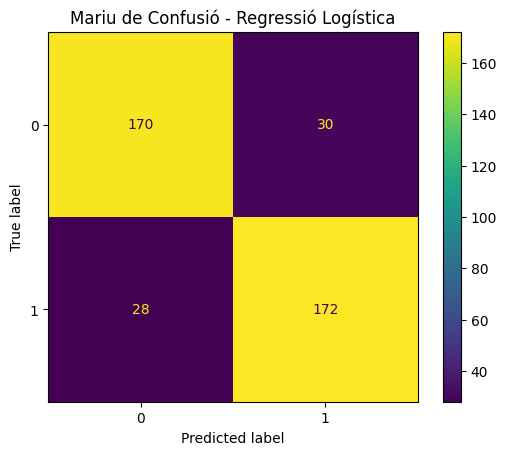

In [51]:
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Mariu de Confusió - Regressió Logística")
plt.show()

In [60]:
errors = [i for i in range(len(y_val)) if y_val[i] != y_pred[i]]

error_texts = [val_texts[i] for i in errors]

print("Número de errores:", len(errors))

# Separar errores en Falsos Positivos y Falsos Negativos
fp_indices = [i for i in range(len(y_val)) if y_val[i] == 0 and y_pred[i] == 1]
fn_indices = [i for i in range(len(y_val)) if y_val[i] == 1 and y_pred[i] == 0]

fp_texts = [val_texts[i] for i in fp_indices]
fn_texts = [val_texts[i] for i in fn_indices]

print(f"Total de errores: {len(errors)}")
print(f"🔸 Falsos Positivos (Negativa -> Positiva): {len(fp_indices)}")
print(f"🔹 Falsos Negativos (Positiva -> Negativa): {len(fn_indices)}")

Número de errores: 58
Total de errores: 58
🔸 Falsos Positivos (Negativa -> Positiva): 30
🔹 Falsos Negativos (Positiva -> Negativa): 28


In [59]:
from collections import Counter

# Extraemos la función de preprocesado y tokenización del vectorizer
analyzer = vectorizer.build_analyzer()

# Procesamos los textos erróneos usando el filtro oficial del modelo
words = []
for text in error_texts:
    words.extend(analyzer(text))

common_words = Counter(words).most_common(20)

print("Palabras más comunes en errores:")
for w, c in common_words:
    print(w, c)

Palabras más comunes en errores:
film 328
movie 141
like 94
just 82
time 71
story 66
good 65
little 53
people 51
characters 50
director 46
character 46
know 44
plot 44
scenes 44
end 43
films 42
does 42
make 42
man 41


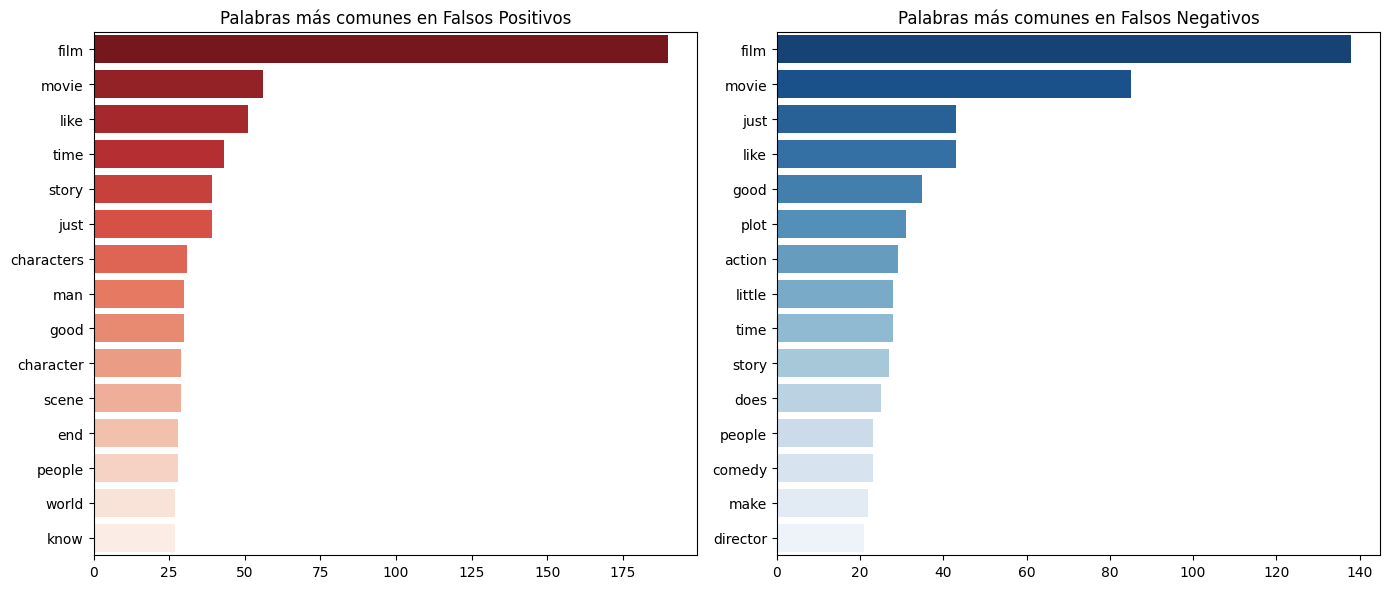

In [62]:
import seaborn as sns

def get_top_n_words(texts, n=15):
    words = []
    for text in texts:
        words.extend(analyzer(text))
    return Counter(words).most_common(n)

top_fp = get_top_n_words(fp_texts)
top_fn = get_top_n_words(fn_texts)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico Falsos Positivos
sns.barplot(x=[c for w, c in top_fp], y=[w for w, c in top_fp], ax=axes[0], palette="Reds_r")
axes[0].set_title("Palabras más comunes en Falsos Positivos")

# Gráfico Falsos Negativos
sns.barplot(x=[c for w, c in top_fn], y=[w for w, c in top_fn], ax=axes[1], palette="Blues_r")
axes[1].set_title("Palabras más comunes en Falsos Negativos")

plt.tight_layout()
plt.show()

Longitud media en errores: 302.72 (Max: 877, Min: 85)
Longitud media en aciertos: 323.19


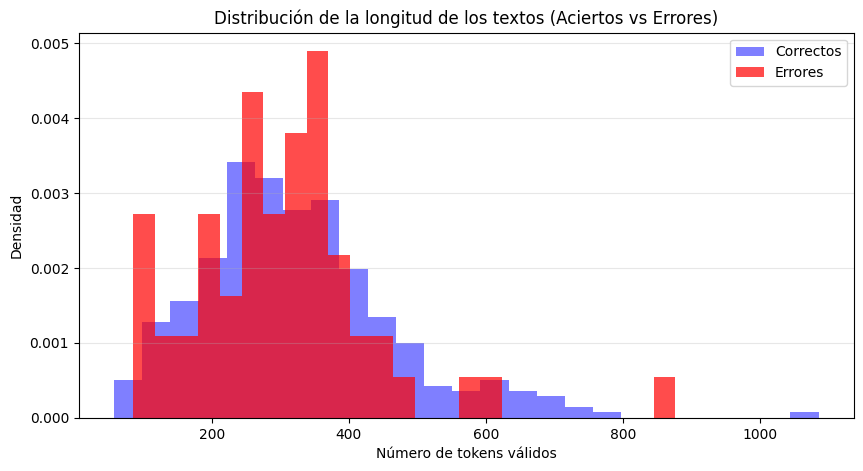

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Usar el analyzer para contar palabras reales procesadas
lengths_errors = [len(analyzer(t)) for t in error_texts]
correct_texts = [val_texts[i] for i in range(len(y_val)) if y_val[i] == y_pred[i]]
lengths_correct = [len(analyzer(t)) for t in correct_texts]

print(f"Longitud media en errores: {np.mean(lengths_errors):.2f} (Max: {np.max(lengths_errors)}, Min: {np.min(lengths_errors)})")
print(f"Longitud media en aciertos: {np.mean(lengths_correct):.2f}")

plt.figure(figsize=(10, 5))
plt.hist(lengths_correct, bins=25, alpha=0.5, label='Correctos', color='blue', density=True)
plt.hist(lengths_errors, bins=25, alpha=0.7, label='Errores', color='red', density=True)
plt.title("Distribución de la longitud de los textos (Aciertos vs Errores)")
plt.xlabel("Número de tokens válidos")
plt.ylabel("Densidad")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [63]:
import textwrap

print("EJEMPLOS DE ERRORES:\n" + "="*50)
for i in errors[:5]:
    real_label = "Positivo" if y_val[i] == 1 else "Negativo"
    pred_label = "Positivo" if y_pred[i] == 1 else "Negativo"
    error_type = "Falso Negativo" if y_val[i] == 1 else "Falso Positivo"
    
    print(f"👉 TIPO: {error_type} (Real: {real_label} | Predicción: {pred_label})")
    print("-" * 50)
    # Mostramos los primeros 400 caracteres formateados para leer fácilmente sin scroll horizontal
    print(textwrap.fill(val_texts[i][:400] + "...", width=80))
    print("=" * 50 + "\n")

EJEMPLOS DE ERRORES:
👉 TIPO: Falso Negativo (Real: Positivo | Predicción: Negativo)
--------------------------------------------------
notice : this is a review and analysis of exotica .  the first part of this
piece is the review , the second part contains some analysis of the movie which
might be construed as spoilers .  if you have not seen the movie and after
reading the first part you intend to do so , then save the second part for the
discussion afterwards .  starring : bruce greenwood , mia kirshner , elias
kosteas , don m...

👉 TIPO: Falso Negativo (Real: Positivo | Predicción: Negativo)
--------------------------------------------------
jacques tati's 1953 classic " les vacances de m . hulot " ( also known as " mr .
hulot's vacation , " in english ) ought to be the textbook on how to do non ?
dialogue comedy in film .  the characters hardly ever speak to each other
directly , and the film operates on the paper ? thin premise that monsieur hulot
, played by tati himself , is aw